In [55]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [56]:
# firstly we need to load the dataset 
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [57]:
# Now we will see the details about the dataset basically we have to do EDA(Exploratory Data Analysis)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [58]:
df.shape

(2640, 12)

In [59]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')

by seeing the above cloumns now I can clearly see that I need to predict the Estimated_Deliveries and rest are my inputs, here is one another thing that I have noticed is that we do not Source_Type for prediction as what is the use of the source of data in pricting the desired output as well CO2_Saved_tons is also not contributing anything 


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [61]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [62]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

There are no null values in the dataframe and now lets see the duplicates if any 

In [63]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


Regions: <StringArray>
['Europe', 'Asia', 'North America', 'Middle East']
Length: 4, dtype: str
Models: <StringArray>
['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Length: 5, dtype: str
Source types: <StringArray>
['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']
Length: 3, dtype: str
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64


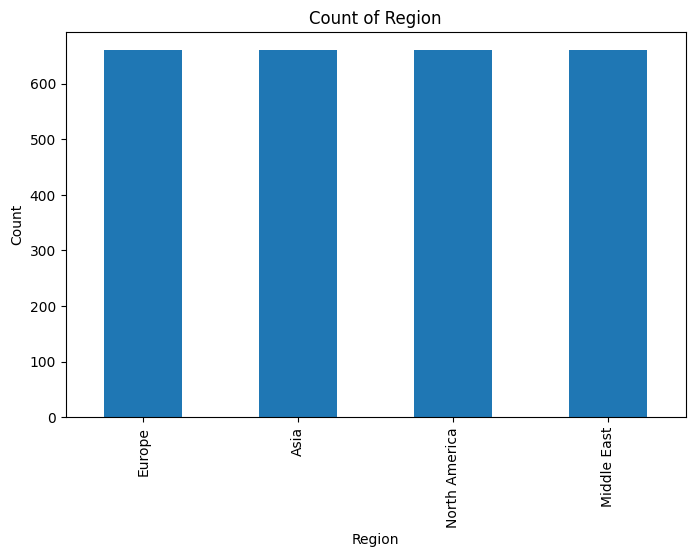

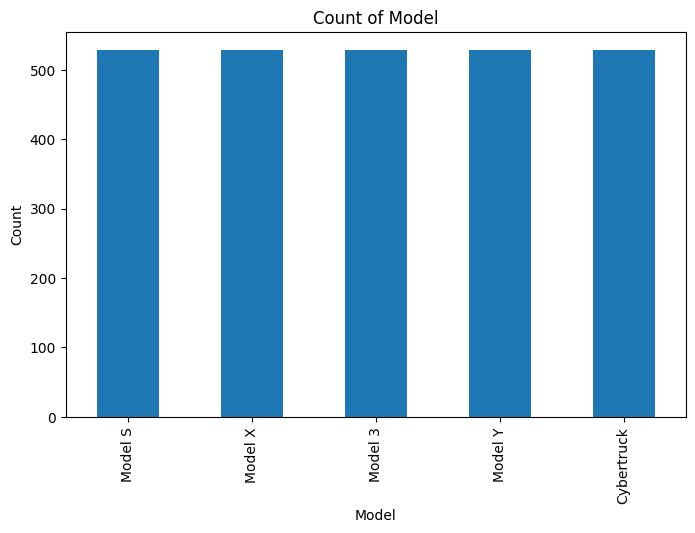

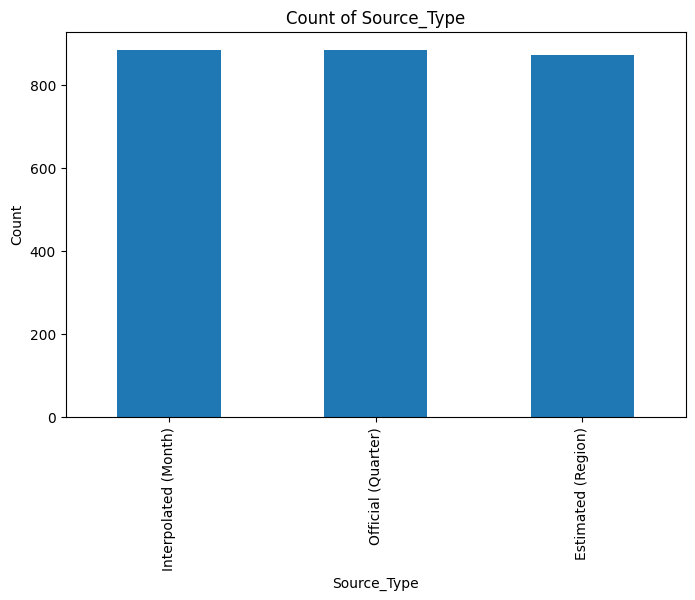

In [64]:
# For text/category columns, check unique values
print("Regions:", df['Region'].unique())
print("Models:", df['Model'].unique())
print("Source types:", df['Source_Type'].unique())

# Count how many rows per category
print(df['Region'].value_counts())
print(df['Model'].value_counts())


cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8, 5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

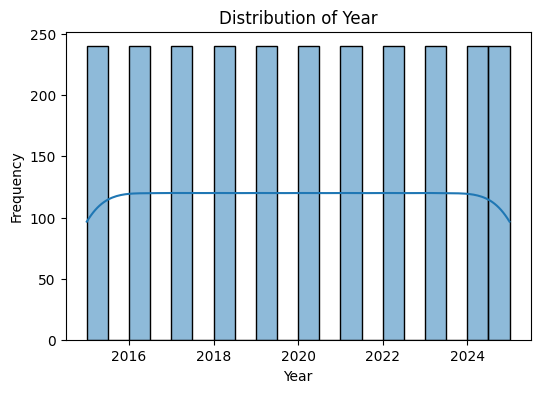

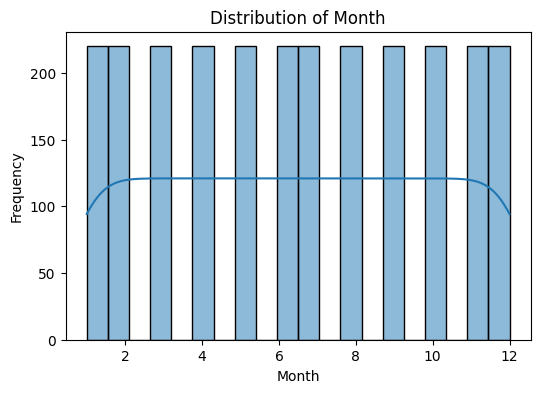

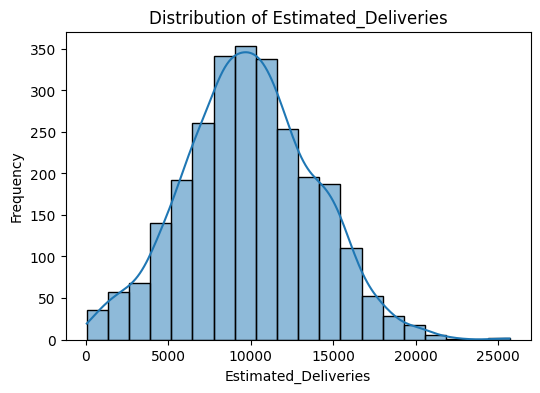

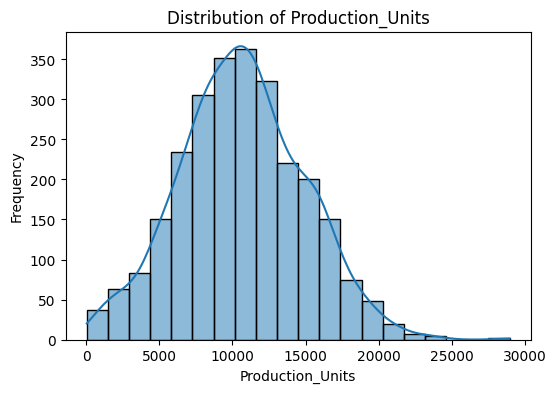

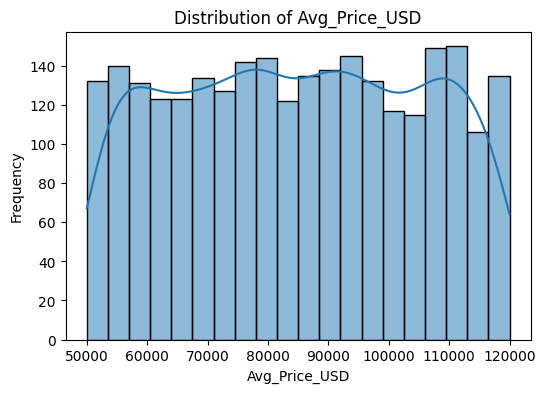

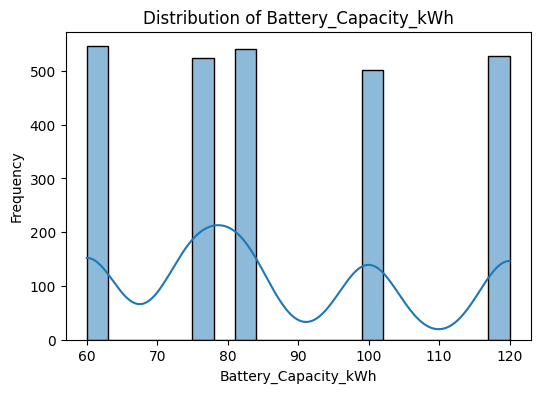

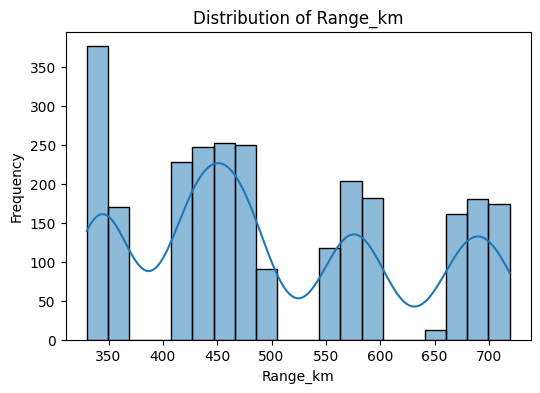

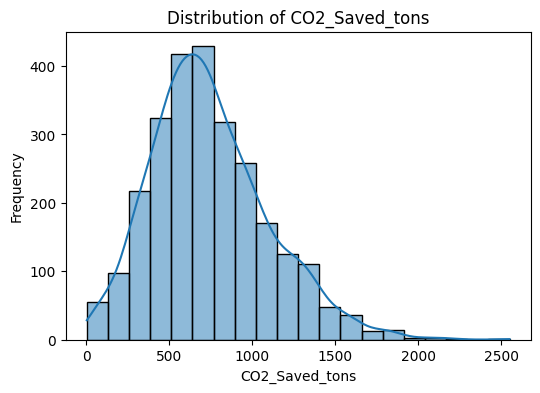

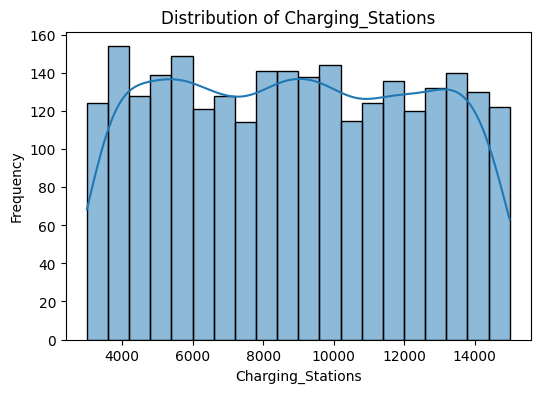

In [65]:
import seaborn as sns

numeric_cols = [
    'Year',
    'Month',
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

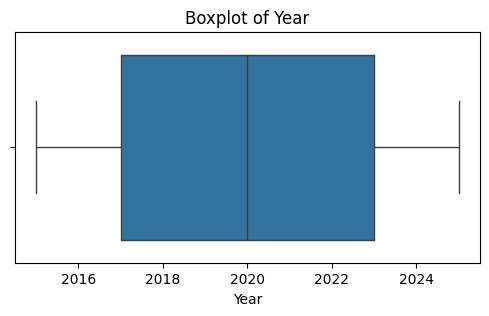

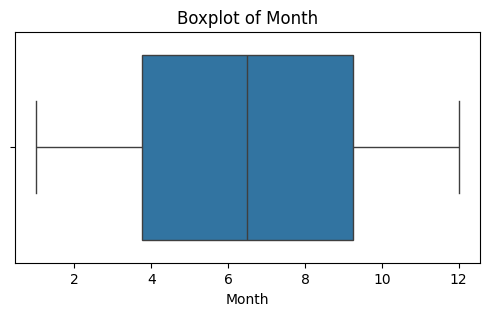

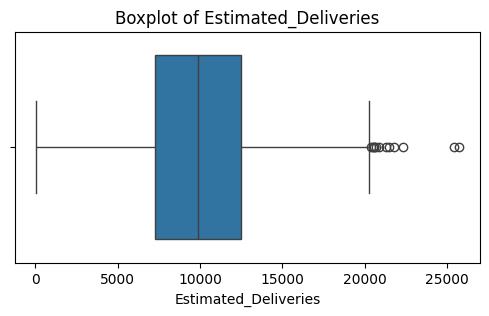

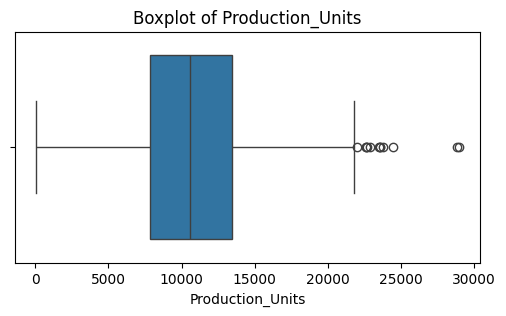

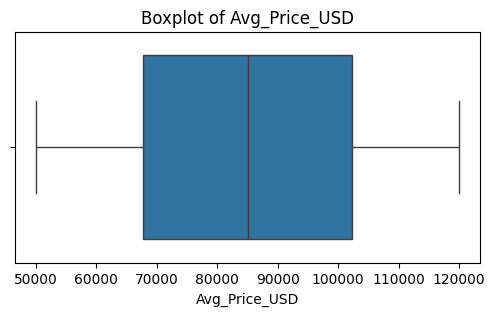

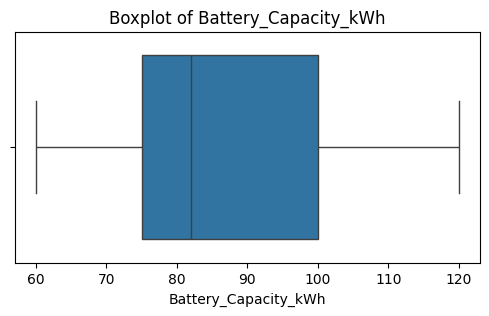

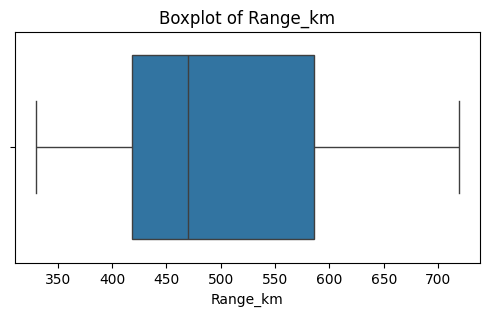

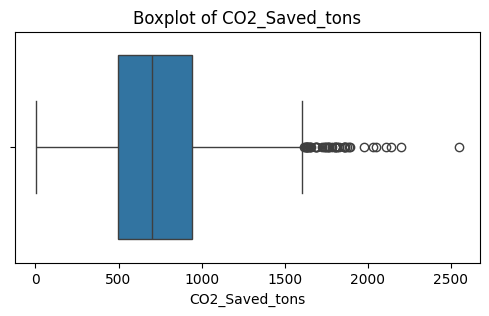

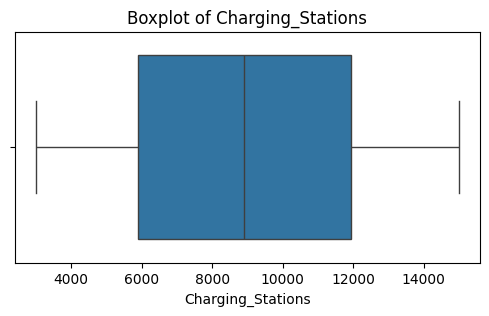

In [66]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

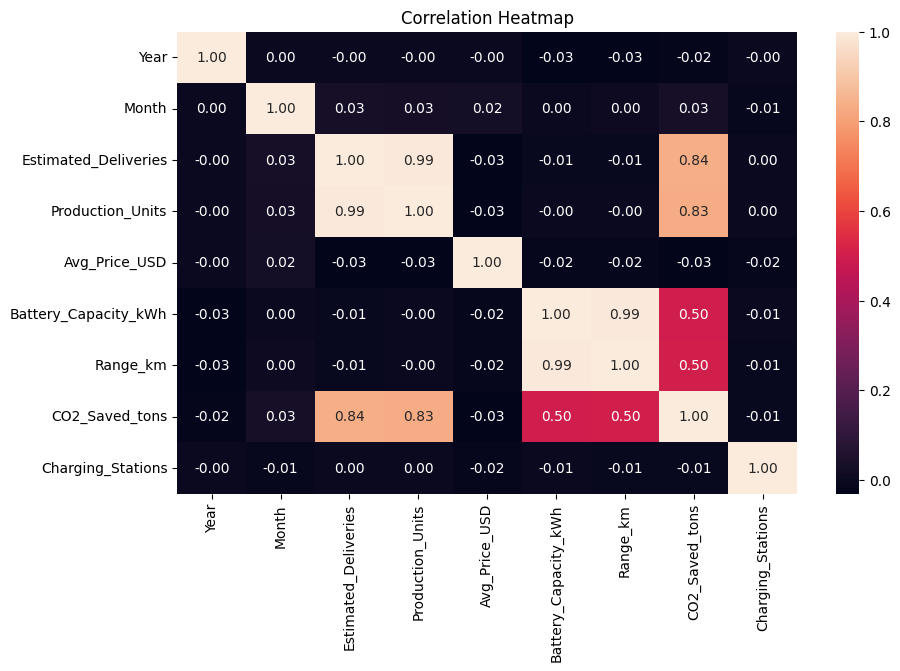

In [67]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

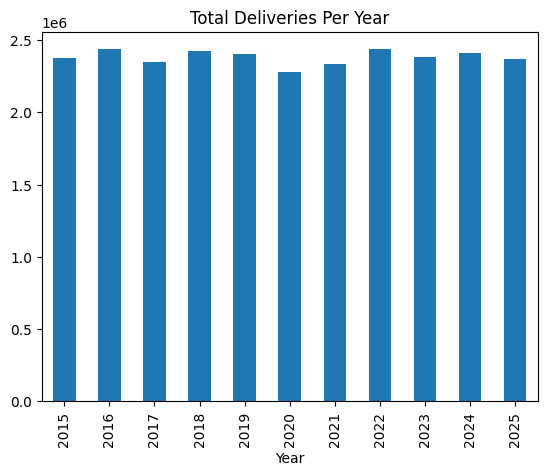

In [68]:
# 1. How have deliveries changed over the years?
df.groupby('Year')['Estimated_Deliveries'].sum().plot(kind='bar')
plt.title('Total Deliveries Per Year')
plt.show()

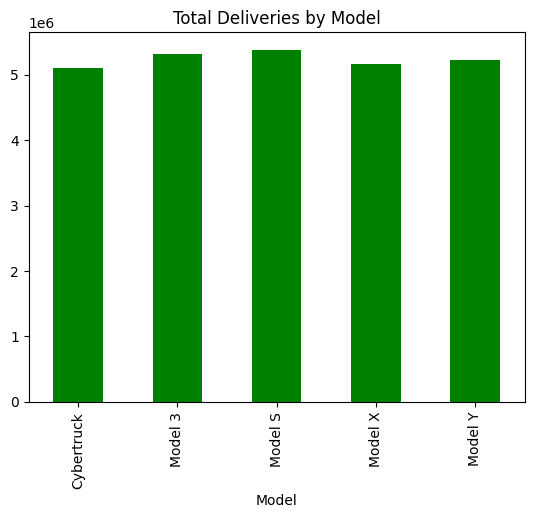

In [69]:
# 2. Which model is most popular?
df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar', color='green')
plt.title('Total Deliveries by Model')
plt.show()

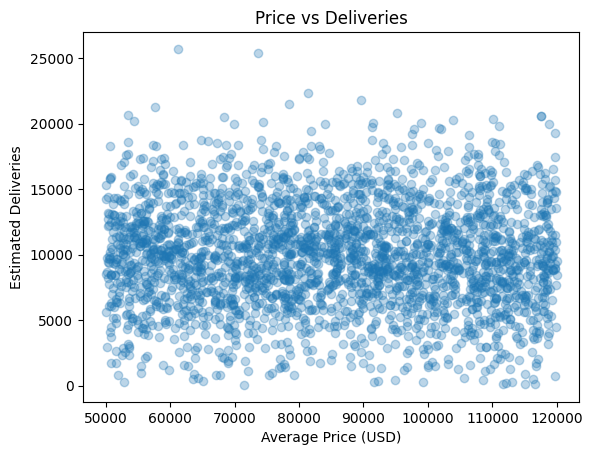

In [70]:
# 4. Does price affect deliveries? (Scatter plot)
plt.scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'], alpha=0.3)
plt.xlabel('Average Price (USD)')
plt.ylabel('Estimated Deliveries')
plt.title('Price vs Deliveries')
plt.show()

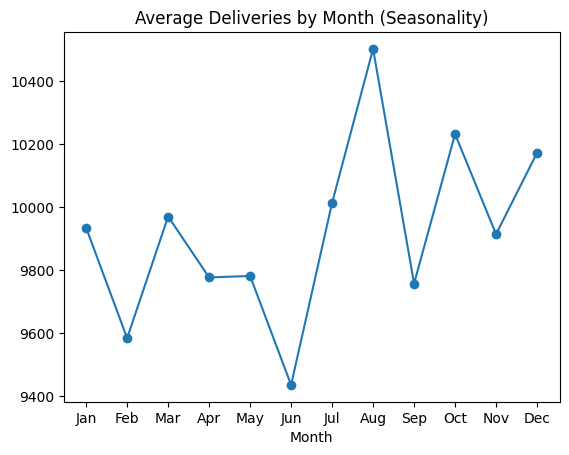

In [71]:
# 5. How do deliveries vary by month? (Seasonality)
df.groupby('Month')['Estimated_Deliveries'].mean().plot(kind='line', marker='o')
plt.title('Average Deliveries by Month (Seasonality)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

In [72]:

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'    # Low deliveries
    elif month in [3, 4, 5]:
        return 'Spring'    # Building up
    elif month in [6, 7, 8]:
        return 'Summer'    # Mixed - Aug high, Jun low
    else:
        return 'Fall'      # Sep-Oct-Nov — quarter end push

df['Season'] = df['Month'].apply(get_season)
print(df['Season'].value_counts())

Season
Spring    660
Winter    660
Fall      660
Summer    660
Name: count, dtype: int64


Quarter
2    660
1    660
4    660
3    660
Name: count, dtype: int64


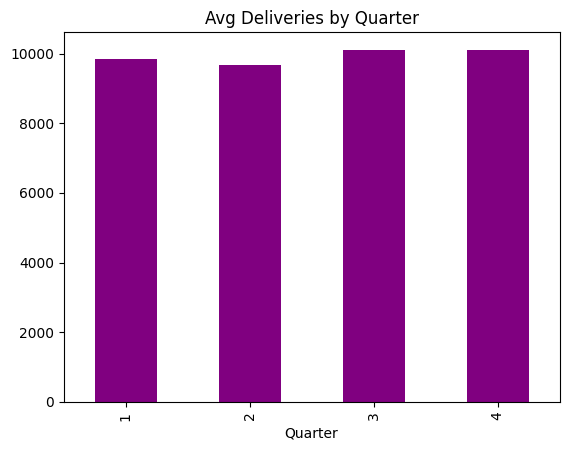

In [73]:
# Create a 'Quarter' column — very useful for Tesla's business pattern
df['Quarter'] = df['Month'].apply(lambda m: (m - 1) // 3 + 1)
# Month 1,2,3 → Q1
# Month 4,5,6 → Q2
# Month 7,8,9 → Q3
# Month 10,11,12 → Q4

print(df['Quarter'].value_counts())

# Now check if quarter-end months have higher deliveries
df.groupby('Quarter')['Estimated_Deliveries'].mean().plot(kind='bar', color='purple')
plt.title('Avg Deliveries by Quarter')
plt.show()

In [74]:
# Create 'is_quarter_end' flag — month 3, 6, 9, 12 are quarter ends
df['is_quarter_end'] = df['Month'].apply(lambda m: 1 if m in [3, 6, 9, 12] else 0)

# Compare: quarter end months vs normal months
print("Quarter-end month avg deliveries:", 
      df[df['is_quarter_end']==1]['Estimated_Deliveries'].mean().round(0))
print("Normal month avg deliveries:     ", 
      df[df['is_quarter_end']==0]['Estimated_Deliveries'].mean().round(0))

Quarter-end month avg deliveries: 9833.0
Normal month avg deliveries:      9967.0


EDA CONCLUSIONS:
- No missing values, no duplicates → data is clean
- Target variable: Estimated_Deliveries (range: 48 to 25,704)
- August has highest avg deliveries, June has lowest
- All regions and models are equally balanced
- Price has NO strong relationship with deliveries (scatter plot showed random spread)
- CO2_Saved_tons has 0.84 correlation but it's derived FROM deliveries → drop it
- Source_Type is just metadata → drop it
- is_quarter_end shows no real pattern in this data → drop it
- New useful features created: Season, Quarter

# PreProcessing 

In [75]:
df_cleaned = df.copy()

print("Original df shape:", df.shape)
print("Copy shape:", df_cleaned.shape)

Original df shape: (2640, 15)
Copy shape: (2640, 15)


In [76]:
df_cleaned = df_cleaned.drop(columns=['CO2_Saved_tons', 'Source_Type', 'is_quarter_end'])

print("Columns remaining:", df_cleaned.columns.tolist())
print("Shape now:", df_cleaned.shape)
# Should show (2640, 11) — dropped 3 columns

Columns remaining: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Season', 'Quarter']
Shape now: (2640, 12)


In [77]:
df_cleaned = pd.get_dummies(df_cleaned,
                             columns=['Region', 'Model', 'Season'],
                             drop_first=True)

df_cleaned = df_cleaned.astype({col: int for col in df_cleaned.select_dtypes(bool).columns})

print("Shape after encoding:", df_cleaned.shape)
print("\nAll columns now:")
for col in df_cleaned.columns:
    print(" →", col)

Shape after encoding: (2640, 19)

All columns now:
 → Year
 → Month
 → Estimated_Deliveries
 → Production_Units
 → Avg_Price_USD
 → Battery_Capacity_kWh
 → Range_km
 → Charging_Stations
 → Quarter
 → Region_Europe
 → Region_Middle East
 → Region_North America
 → Model_Model 3
 → Model_Model S
 → Model_Model X
 → Model_Model Y
 → Season_Spring
 → Season_Summer
 → Season_Winter


In [78]:
# y = the answer we want to predict
y = df_cleaned['Estimated_Deliveries']

# X = all inputs (drop the answer column)
X = df_cleaned.drop(columns=['Estimated_Deliveries'])

print("X shape:", X.shape)   # (2640, 21) — 21 input features
print("y shape:", y.shape)   # (2640,)    — 2640 answers

print("\nFirst 3 values of y (actual deliveries):")
print(y.head(3).values)

X shape: (2640, 18)
y shape: (2640,)

First 3 values of y (actual deliveries):
[17646  3797  8411]


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% goes to test set
    random_state=42    # fixed seed — so you get same split every time you run
)

print("X_train shape:", X_train.shape)   # (2112, 21)
print("X_test shape: ", X_test.shape)    # (528, 21)
print("y_train shape:", y_train.shape)   # (2112,)
print("y_test shape: ", y_test.shape)    # (528,)

print(f"\nTraining on {X_train.shape[0]} rows")
print(f"Testing on  {X_test.shape[0]} rows")

X_train shape: (2112, 18)
X_test shape:  (528, 18)
y_train shape: (2112,)
y_test shape:  (528,)

Training on 2112 rows
Testing on  528 rows


In [80]:
from sklearn.preprocessing import StandardScaler

# Only scale numeric columns — NOT the 0/1 encoded columns
# (0/1 columns are already in a good range, no need to scale them)
cols_to_scale = ['Year', 'Month', 'Avg_Price_USD',
                 'Battery_Capacity_kWh', 'Range_km',
                 'Charging_Stations', 'Quarter',
                 'Production_Units']

scaler = StandardScaler()

# LEARN from train, APPLY to train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# ONLY APPLY to test (never learn from test!)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("✅ Scaling done!")
print("\nFirst row of X_train after scaling:")
print(X_train.iloc[0])
# You'll see small decimal numbers like -1.2, 0.4, 0.03 etc.

✅ Scaling done!

First row of X_train after scaling:
Year                    0.632488
Month                  -1.301132
Production_Units        0.141161
Avg_Price_USD          -1.686008
Battery_Capacity_kWh   -1.296941
Range_km               -1.274752
Charging_Stations       0.571578
Quarter                -1.339019
Region_Europe           0.000000
Region_Middle East      0.000000
Region_North America    1.000000
Model_Model 3           0.000000
Model_Model S           0.000000
Model_Model X           0.000000
Model_Model Y           0.000000
Season_Spring           0.000000
Season_Summer           0.000000
Season_Winter           1.000000
Name: 2387, dtype: float64


In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Create the model
lr_model = LinearRegression()

# Train it — show it X_train and y_train so it learns the pattern
lr_model.fit(X_train, y_train)

# Now predict on X_test (data it never saw before)
y_pred_lr = lr_model.predict(X_test)

# Measure how good the predictions are
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("── Linear Regression Results ──")
print(f"RMSE : {rmse_lr:.2f}")
print(f"MAE  : {mae_lr:.2f}")
print(f"R²   : {r2_lr:.4f}")

── Linear Regression Results ──
RMSE : 417.71
MAE  : 340.52
R²   : 0.9883


In [82]:
from sklearn.ensemble import RandomForestRegressor

# Create the model — 100 trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train it
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Measure
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("── Random Forest Results ──")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

── Random Forest Results ──
RMSE : 456.19
MAE  : 364.33
R²   : 0.9860


In [83]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE':  [rmse_lr, rmse_rf],
    'MAE':   [mae_lr,  mae_rf],
    'R²':    [r2_lr,   r2_rf]
})

print(results.to_string(index=False))
print("\nBetter model:", results.loc[results['R²'].idxmax(), 'Model'])

            Model       RMSE        MAE       R²
Linear Regression 417.709870 340.516995 0.988295
    Random Forest 456.192495 364.329773 0.986039

Better model: Linear Regression


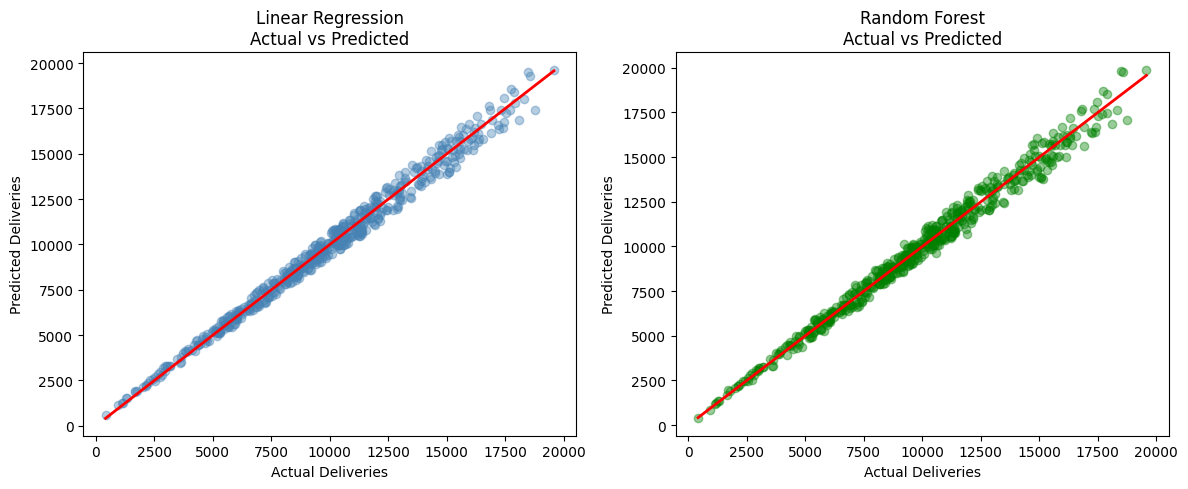

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Regression plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=2)
axes[0].set_title('Linear Regression\nActual vs Predicted')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')

# Random Forest plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.4, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=2)
axes[1].set_title('Random Forest\nActual vs Predicted')
axes[1].set_xlabel('Actual Deliveries')
axes[1].set_ylabel('Predicted Deliveries')

plt.tight_layout()
plt.show()